In [1]:
import torch
import torch.nn as nn

from pathlib import Path
import pandas as pd
import numpy as np

In this section we will implement the LSTM architecture.
We already plot-process the data.

In [2]:
# Reading processed data.
data=pd.read_csv("data/data_processed.csv")
print(data.shape)
print(data.head())
print(data.tail())


(52416, 3)
              datetime   time  consumption
0  2025-07-01 00:00:00  00:00    34.055696
1  2025-07-01 00:10:00  00:10    29.814684
2  2025-07-01 00:20:00  00:20    29.128101
3  2025-07-01 00:30:00  00:30    28.228861
4  2025-07-01 00:40:00  00:40    27.335696
                  datetime   time  consumption
52411  2026-06-29 23:10:00  23:10    31.160456
52412  2026-06-29 23:20:00  23:20    30.430418
52413  2026-06-29 23:30:00  23:30    29.590875
52414  2026-06-29 23:40:00  23:40    28.958175
52415  2026-06-29 23:50:00  23:50    28.349810


In [3]:
consumption_data = data['consumption'].values.reshape(-1, 1)
tensor_data = torch.tensor(consumption_data, dtype=torch.float32)


In [4]:
def create_sequences(data_tensor, seq_length):
    xs = []
    ys = []
    for i in range(len(data_tensor) - seq_length):
        x = data_tensor[i : (i + seq_length)]
        y = data_tensor[i + seq_length]
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.stack(ys)

In [5]:
# 60 is the window length in steps, not the stride; the stride is 1.
# Superseded: the revised experiment uses 6 steps (one hour). See lstm_forecast.py.
SEQUENCE_LENGTH = 60

In [6]:
X, y = create_sequences(tensor_data, SEQUENCE_LENGTH)


In [7]:
train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print("Train Set Size (X, y):", X_train.shape, y_train.shape)
print("Test size data:", X_test.shape,y_test.shape)


Train Set Size (X, y): torch.Size([41884, 60, 1]) torch.Size([41884, 1])
Test size data: torch.Size([10472, 60, 1]) torch.Size([10472, 1])


[BATCH SIZE , SEQUENCE_LENGTH , FEATURES]

In [8]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
device="cuda" if torch.cuda.is_available() else "cpu"
# bidirectional=False by default. Change it after new session.
class LSTM(nn.Module):
    def __init__(self,input_size,hidden_size,num_stacked_layers):
        super().__init__()
        self.num_stacked_layers=num_stacked_layers
        self.fc=nn.Linear(hidden_size,1)
        self.lstm=nn.LSTM(input_size,hidden_size,num_stacked_layers,batch_first=True)

        self.hidden_size=hidden_size
    def forward(self,x):
        batch_size=x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)
        return out


        



In [10]:
import torch.optim as optim
INPUT_SIZE = 1           
HIDDEN_SIZE = 64         
NUM_STACKED_LAYERS = 2 # Change it later.

model = LSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_STACKED_LAYERS).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
# VALIDATION
EPOCHS = 10
for epoch in range(EPOCHS):
    model.train() 
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
       
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {epoch_loss:.4f}")

Epoch [1/10] - Train Loss: 248.0716
Epoch [2/10] - Train Loss: 49.5510
Epoch [3/10] - Train Loss: 20.2190
Epoch [4/10] - Train Loss: 1.9236
Epoch [5/10] - Train Loss: 0.7210
Epoch [6/10] - Train Loss: 0.4287
Epoch [7/10] - Train Loss: 0.3171
Epoch [8/10] - Train Loss: 0.2547
Epoch [9/10] - Train Loss: 0.2266
Epoch [10/10] - Train Loss: 0.2154


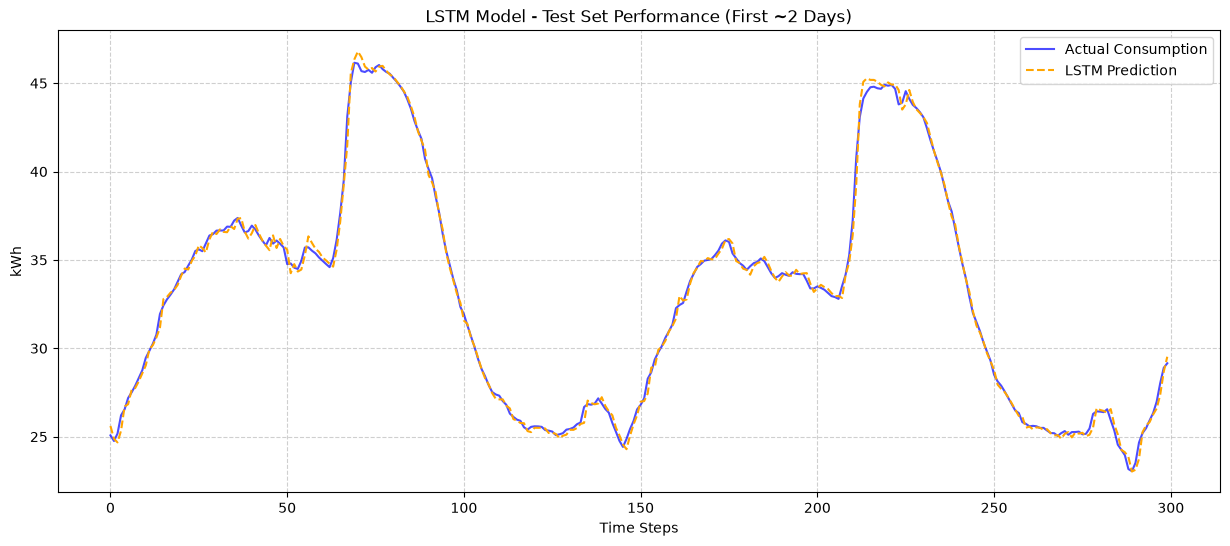

In [13]:
import matplotlib.pyplot as plt
model.eval() 
test_predictions = []
test_actuals = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        
        preds = model(batch_X)
        
        
        test_predictions.append(preds.cpu().numpy())
        test_actuals.append(batch_y.numpy())

test_predictions = np.vstack(test_predictions)
test_actuals = np.vstack(test_actuals)
plots_dir = Path('plots')
plots_dir.mkdir(exist_ok=True)

plt.figure(figsize=(15, 6))

plt.plot(test_actuals[:300], label='Actual Consumption', color='blue', alpha=0.7)
plt.plot(test_predictions[:300], label='LSTM Prediction', color='orange', linestyle='--')

plt.title('LSTM Model - Test Set Performance (First ~2 Days)')
plt.xlabel('Time Steps')
plt.ylabel('Consumption')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig(plots_dir / 'lstm_model_forecast_1.png', dpi=300, bbox_inches='tight')

plt.show()

In [14]:
y_true = test_actuals.reshape(-1)
y_pred = test_predictions.reshape(-1)

errors = y_true - y_pred

test_mse = np.mean(errors ** 2)
test_rmse = np.sqrt(test_mse)
test_mae = np.mean(np.abs(errors))

nonzero = y_true != 0
test_mape = np.mean(np.abs(errors[nonzero] / y_true[nonzero])) * 100

ss_res = np.sum(errors ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
test_r2 = 1 - ss_res / ss_tot

print("TEST set metrics :")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAE  : {test_mae:.4f}")
print(f"MAPE : {test_mape:.2f}%")
print(f"R2   : {test_r2:.4f}")


TEST set metrics :
MSE  : 0.1610
RMSE : 0.4013
MAE  : 0.2749
MAPE : 0.98%
R2   : 0.9958


In [15]:
import json
import os

current_run = {
    "experiment_name": "lstm_v1_baseline", 
    "hyperparameters": {
        "input_size": INPUT_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_stacked_layers": NUM_STACKED_LAYERS,
        "batch_size": BATCH_SIZE,
        "sequence_length": 60,
        "learning_rate": 0.001,
        "epochs": 10
    },
    "results": {
        "final_train_loss": float(epoch_loss), 
        "test_mse": float(test_mse),
        "test_rmse": float(test_rmse),
        "test_mae": float(test_mae),
        "test_mape": float(test_mape),
        "test_r2": float(test_r2)
    }
}

log_file = "hyperparameter_logs.json"
existing_runs = []

if os.path.exists(log_file):
    with open(log_file, "r", encoding="utf-8") as f:
        try:
            existing_runs = json.load(f)
        except json.JSONDecodeError:
            pass 

existing_runs.append(current_run)

with open(log_file, "w", encoding="utf-8") as f:
    json.dump(existing_runs, f, indent=4, ensure_ascii=False)

print(f" '{log_file}' saved succesfully!")

 'hyperparameter_logs.json' saved succesfully!


Save model.


In [16]:
model_save =  "model/lstm_model_1.pth"
torch.save(model.state_dict(), model_save)
